In [1]:
using LinearAlgebra
using Random
using Statistics
using Plots
using LaTeXStrings

include("../src/jordan_lake_domain.jl")
include("../src/stgpkf.jl")

Main.STGPKF

In [2]:
T = 3600 # s
λₛ = 1 / 0.4 # 1 / km
σ = 0.5
λₜ = 1 / 3000 # 1 / s
σᵣ = 0.01
Δt = 2 # s

kₛ(𝐬₁, 𝐬₂) = exp(-λₛ * norm(𝐬₁ - 𝐬₂))
kₜ(t₁, t₂) = σ^2 * exp(-λₜ * (t₁ - t₂))
k(𝐬₁, t₁, 𝐬₂, t₂) = kₛ(𝐬₁, 𝐬₂) * kₜ(t₁, t₂)

𝐬 = JordanLakeDomain.𝐬
M = length(𝐬)

𝐊ₘ = reshape([kₛ(𝐬[j], 𝐬[i]) for i = 1:M for j = 1:M], (M, M))

𝐊ₘʰᵃˡᶠ = cholesky(𝐊ₘ).L
# 𝐊ₘʰᵃˡᶠ = sqrt(𝐊ₘ)

F = -λₜ
G = 1
H = σ * sqrt(2 * λₜ)
Σ₀ = 1 / (2 * λₜ)
𝐇ᵇᵃʳ = Diagonal(H * ones(M))

# Simulate 𝐱ᵢ for all i ∈ {1, ..., T / Δt}
𝐱 = zeros(M, Int(T / Δt))

Random.seed!(3)
𝐯ᵢ = sqrt(Σ₀) * randn(M)
for i = 1:Int(T / Δt)
    𝐰ᵢᵗⁱˡᵈᵉ = sqrt(1 / (2 * λₜ) * (1 - exp(-2 * λₜ * Δt))) * randn(M)
    𝐯ᵢ = exp(-λₜ * Δt) * 𝐯ᵢ + 𝐰ᵢᵗⁱˡᵈᵉ
    𝐳ᵢ = H * 𝐯ᵢ
    𝐱[:, i] = 𝐊ₘʰᵃˡᶠ * 𝐳ᵢ
end
𝐱
maximum(𝐱)
minimum(𝐱)
ans = mean(𝐱, dims=2)
maximum(ans)
minimum(ans)
mean(ans)
ans = std(𝐱, dims=2)
maximum(ans)
minimum(ans)
mean(ans)
# Simulation is complete


0.2488076420196753

In [3]:
𝐱

203×1800 Matrix{Float64}:
  0.334859    0.353801    0.347138    …  -0.0722616  -0.07393    -0.0732855
  0.673787    0.693782    0.672559       -0.355275   -0.370836   -0.395191
  0.581874    0.573537    0.55784        -0.178981   -0.185026   -0.198651
  0.141588    0.147208    0.124144       -0.122294   -0.136116   -0.132402
  0.117109    0.121068    0.101128        0.44065     0.436621    0.451561
  0.148113    0.117855    0.0919907   …   0.196361    0.201338    0.198228
 -0.46159    -0.486744   -0.497814       -0.411001   -0.44689    -0.46062
 -0.0498678  -0.0624539  -0.100679        0.413146    0.405212    0.421726
 -0.499802   -0.554874   -0.571117        0.486352    0.480774    0.477448
 -0.364851   -0.39426    -0.410805       -0.213886   -0.213245   -0.202862
  ⋮                                   ⋱                          
 -0.0206577  -0.0232836   0.00342311     -0.586651   -0.57056    -0.5819
  0.476609    0.48616     0.509629    …  -0.0778266  -0.0618128  -0.0847074
  0.50594

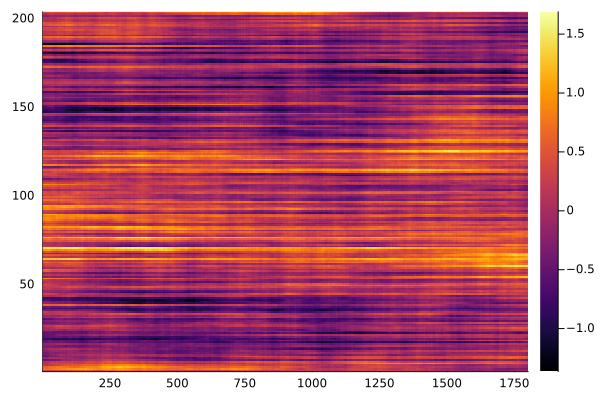

In [4]:
heatmap(𝐱)

In [5]:

# Predict {𝐱ⱼ|j ∈ {i, ..., min(i + 1, T / Δt)}} for all i ∈ {1, ..., T / Δt}
key_parameters_1 = STGPKF.KeyParameters(λₛ, σ, λₜ, σᵣ, Δt)
estimator_1 = STGPKF.Estimator()
STGPKF.initialize!(estimator_1, key_parameters_1)

trajectory = zeros(Int64, Int(T / Δt))
# Initialize a transect trajectory
num_of_points_on_trajectory = 0
half_transect_trajectory = [1:2; 4:-1:3; 5:7; 10:-1:8; 11:14; 18:-1:15;
    19:23; 28:-1:24; 29:33; 38:-1:34; 39:43; 48:-1:44; 49:53; 58:-1:54;
    59:64; 70:-1:65; 71:76; 82:-1:77; 83:88; 94:-1:89; 95:100;
    106:-1:101; 107:112; 119:-1:113; 120:126; 132:-1:127; 133:138;
    144:-1:139; 145:150; 156:-1:151; 157:162; 168:-1:163; 169:174;
    179:-1:175; 180:184; 189:-1:185; 190:193; 196:-1:194; 197:199;
    201:-1:200; 202; 203
]
i = 1
while num_of_points_on_trajectory < Int(T / Δt)
    num_of_points_on_trajectory += 1
    trajectory[num_of_points_on_trajectory] = half_transect_trajectory[i]
    i += 1
    if i > length(half_transect_trajectory)
        half_transect_trajectory = reverse(half_transect_trajectory)
        i = 2
    end
end
# Trajectory initialization is complete

# Define variables for plotting
eᴬᵛᵍᴬᵇˢ = zeros(Int(T / Δt)) # average (over all locations) absolute error
σᴬᵛᵍ = zeros(Int(T / Δt)) # average (over all locations) std of actual error
# Definition is complete

for i = 1:Int(T / Δt)
    𝐬ᵢᵗⁱˡᵈᵉ = 𝐬[trajectory[i]]
    yᵢ = 𝐱[trajectory[i], i] + σᵣ * randn() # Collect measurement
    STGPKF.update_and_predict!(estimator_1, key_parameters_1, yᵢ, 𝐬ᵢᵗⁱˡᵈᵉ)

    eᴬᵛᵍᴬᵇˢ[i] = mean(abs.(estimator_1.𝐱ʰᵃᵗⱼₗᵢ[:, 1] - 𝐱[:, i]))
    σᴬᵛᵍ[i] = (1 / M) * tr(sqrt.(Diagonal(diag(
        (𝐊ₘʰᵃˡᶠ * 𝐇ᵇᵃʳ) * estimator_1.𝚺ⱼₗᵢ[:, :, 1] * transpose(𝐊ₘʰᵃˡᶠ * 𝐇ᵇᵃʳ)
    ))))
end
# Prediction is complete


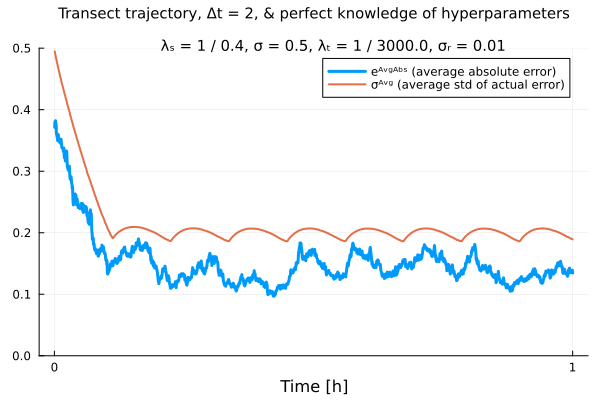

In [6]:

# Plot eᴬᵛᵍᴬᵇˢ and σᴬᵛᵍ
plot((1:Int(T / Δt)) * Δt / 3600, [eᴬᵛᵍᴬᵇˢ, σᴬᵛᵍ], lw=[3 2],
    label=[
    "eᴬᵛᵍᴬᵇˢ (average absolute error)" "σᴬᵛᵍ (average std of actual error)"]);
xlabel!("Time [h]");
xticks!(0:8);
ylims!(0, 0.5);
yticks!(0:0.1:0.5);
display(title!("Transect trajectory, Δt = $Δt, & perfect knowledge of hyperparameters\n
        λₛ = 1 / $(1/λₛ), σ = $σ, λₜ = 1 / $(1/λₜ), σᵣ = $σᵣ",
    titlefontsize=10))


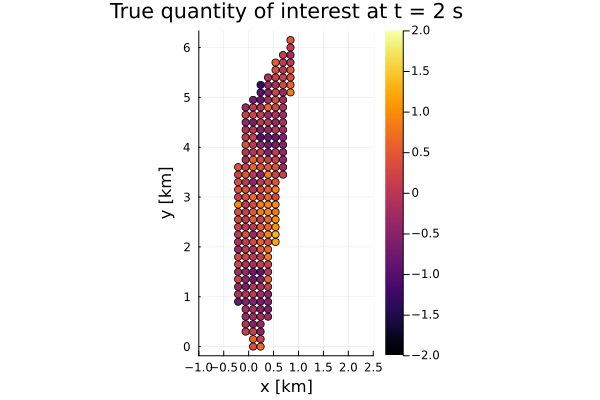

In [7]:

# Plot 𝐱[:, 1]
scatter([x_y[1] for x_y in 𝐬], [x_y[2] for x_y in 𝐬], zcolor=𝐱[:, 1],
    legend=false, colorbar=true, aspect_ratio=:equal, clims=(-2, 2));
xlabel!("x [km]");
xlims!(-1, 2.5);
xticks!(-1:0.5:2.5);
ylabel!("y [km]");
display(title!("True quantity of interest at t = $Δt s"))


┌ Info: Saved animation to /tmp/jl_dKhSRcBYLq.gif
└ @ Plots /home/kmgovind/.julia/packages/Plots/du2dt/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_dKhSRcBYLq.gif")
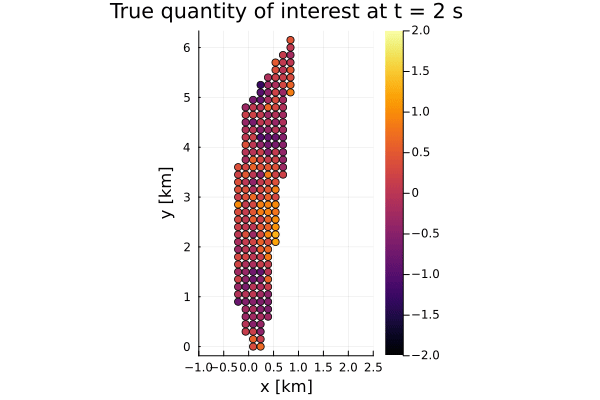

In [8]:
idx, idy = size(𝐱)
windfield = @animate for time_idx in 1:100:idy
    scatter([x_y[1] for x_y in 𝐬], [x_y[2] for x_y in 𝐬], zcolor=𝐱[:, time_idx],
    legend=false, colorbar=true, aspect_ratio=:equal, clims=(-2, 2));
    xlabel!("x [km]");
    xlims!(-1, 2.5);
    xticks!(-1:0.5:2.5);
    ylabel!("y [km]");
    title!("True quantity of interest at t = $(time_idx * Δt) s")
end
gif(windfield)

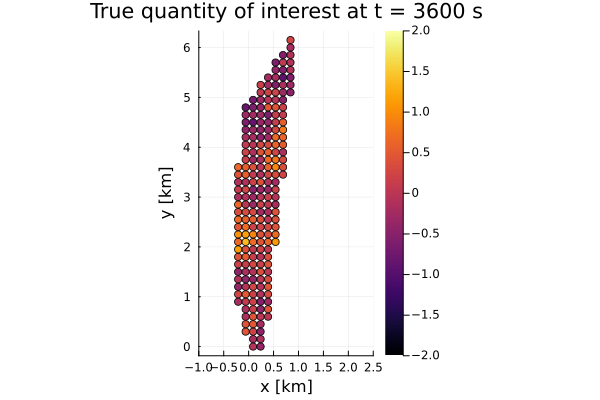

In [9]:

# Plot 𝐱[:, end]
scatter([x_y[1] for x_y in 𝐬], [x_y[2] for x_y in 𝐬], zcolor=𝐱[:, end],
    legend=false, colorbar=true, aspect_ratio=:equal, clims=(-2, 2));
xlabel!("x [km]");
xlims!(-1, 2.5);
xticks!(-1:0.5:2.5);
ylabel!("y [km]");
display(title!("True quantity of interest at t = $T s"))


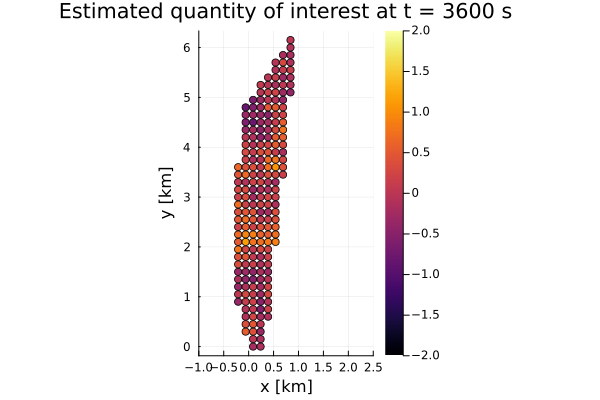

In [10]:

# Plot 𝐱ʰᵃᵗⱼₗᵢ[:, 1]
scatter([x_y[1] for x_y in 𝐬], [x_y[2] for x_y in 𝐬], zcolor=estimator_1.𝐱ʰᵃᵗⱼₗᵢ[:, 1],
    legend=false, colorbar=true, aspect_ratio=:equal, clims=(-2, 2));
xlabel!("x [km]");
xlims!(-1, 2.5);
xticks!(-1:0.5:2.5);
ylabel!("y [km]");
display(title!("Estimated quantity of interest at t = $T s"))
